In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
threads = np.array([1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
tvp_spvm = 28.4
tvp_spvm_diag = 12.8
tvp_dot = 38.4
tvp_axpy = 25.6

spmv: [1.99052227 2.0077956 ]
spmv_diag: [0.41554864 0.39825088]
dot: [1.24580653 1.30859792]
axpy: [1.91102365 2.29774132]


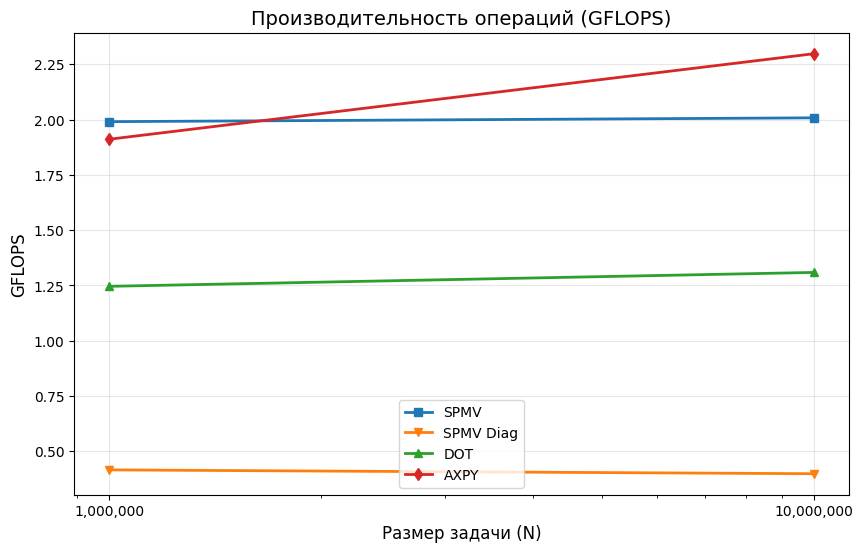

In [6]:
#N=100000, 1000000, 10000000
N =  np.array([
    1000000,
    10000000
])

# Время выполнения отдельных операций (пример)
spmv_times = np.array([
     0.0703333,
     0.747088
])
spmv_diag_times = np.array([
    0.0336904,
    0.376647
])
dot_times  = np.array([
    0.0449508,
    0.458506
])
axpy_times = np.array([
    0.0439555,
    0.391689
])

iterations_done = np.array([
    14,
    15
 ])
spmv_count = np.array([
    10000000,
    100000000
 ])
spmv_diag_count = np.array([
    1000000,
    10000000
 ])
dot_count = np.array([
    2000000,
    20000000
 ])
axpy_count = np.array([
    2000000,
    20000000
 ])

dot_count *= 2
axpy_count *= 3

spmv_gflops = (spmv_count * iterations_done) / spmv_times / 1e9
spmv_diag_gflops = (spmv_diag_count * iterations_done) / spmv_diag_times / 1e9
dot_gflops = (dot_count * iterations_done) / dot_times / 1e9
axpy_gflops = (axpy_count * iterations_done) / axpy_times / 1e9

# График
plt.figure(figsize=(10, 6))
plt.plot(N, spmv_gflops, marker='s', linewidth=2, label='SPMV', markersize=6)
plt.plot(N, spmv_diag_gflops, marker='v', linewidth=2, label='SPMV Diag', markersize=6)
plt.plot(N, dot_gflops, marker='^', linewidth=2, label='DOT', markersize=6)
plt.plot(N, axpy_gflops, marker='d', linewidth=2, label='AXPY', markersize=6)

plt.xlabel('Размер задачи (N)', fontsize=12)
plt.ylabel('GFLOPS', fontsize=12)
plt.title('Производительность операций (GFLOPS)', fontsize=14)
plt.xscale('log')  # Только для N (оси X)
plt.xticks(N, [f'{n:,}' for n in N])  # Красивые подписи для N
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

print("spmv: " + str(spmv_gflops))
print("spmv_diag: " + str(spmv_diag_gflops))
print("dot: " + str(dot_gflops))
print("axpy: " + str(axpy_gflops))

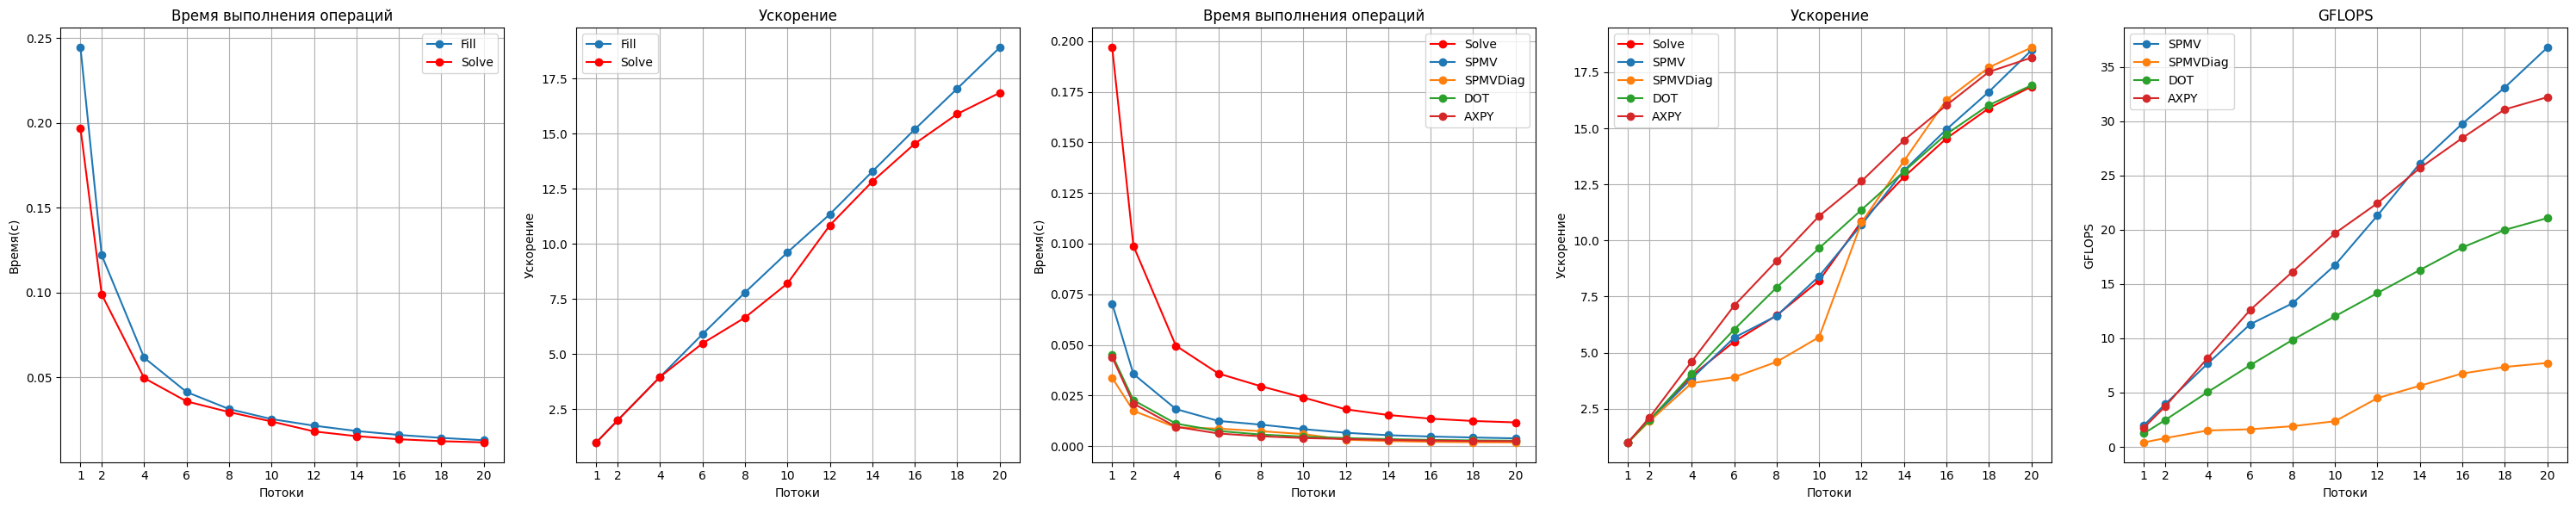

spmv: 36.77407322768668
spmv_diag: 7.728273890026663
dot: 21.07164358819988
axpy: 32.20399164347704


In [ ]:
# Время выполнения операций
generation_time = np.array([
    0.0231606,
    0.0164673,
    0.014104,
    0.0136398,
    0.0136025,
    0.0137668,
    0.0137817,
    0.0140232,
    0.0140312,
    0.0142927,
    0.0142965
])
fill_time = np.array([
    0.244467,
    0.122066,
    0.0615988,
    0.0413647,
    0.0313476,
    0.0254206,
    0.0215396,
    0.0184019,
    0.0160801,
    0.0143389,
    0.0129284
])

solve_times = np.array([
    0.196878,
    0.0989004,
    0.0495798,
    0.0358582,
    0.0295565,
    0.0239882,
    0.0181452,
    0.015342,
    0.0135318,
    0.0123838,
    0.0116785
])


# Время выполнения отдельных операций (пример)
spmv_times = np.array([
    0.0703333,
    0.0355978,
    0.0182816,
    0.012404,
    0.010588,
    0.00836495,
    0.00657089,
    0.00536055,
    0.0047034,
    0.00422953,
    0.00380703
])

spmv_diag_times = np.array([
    0.0336904,
    0.0174119,
    0.00925016,
    0.00862294,
    0.00734144,
    0.00591964,
    0.00311777,
    0.00248609,
    0.00207071,
    0.00190169,
    0.00181153
])

dot_times = np.array([
    0.0449508,
    0.0226682,
    0.0111057,
    0.00745252,
    0.00568565,
    0.00465523,
    0.00395354,
    0.00343722,
    0.00304863,
    0.0028028,
    0.0026576
])

axpy_times = np.array([
    0.0439555,
    0.0209871,
    0.00953756,
    0.00619388,
    0.00483605,
    0.00396417,
    0.00347606,
    0.00303758,
    0.00274212,
    0.00250944,
    0.00242206
])


# =========================
# Параметры операций
# =========================
iterations_done = 14
spmv_count = 10000000
spmv_diag_count = 1000000
dot_count = 2000000
axpy_count = 2000000

dot_count *= 2
axpy_count *= 3

# =========================
# Считаем GFLOPS для каждой операции
# =========================
spmv_gflops = (spmv_count * iterations_done) / spmv_times / 1e9
spmv_diag_gflops = (spmv_diag_count * iterations_done) / spmv_diag_times / 1e9
dot_gflops  = (dot_count  * iterations_done) / dot_times  / 1e9
axpy_gflops = (axpy_count * (iterations_done-1)) / axpy_times / 1e9

# =========================
# Считаем ускорение
# =========================
speedup_generation = generation_time[0] / generation_time
speedup_fill = fill_time[0] / fill_time
speedup_solve = solve_times[0] / solve_times
speedup_spmv  = spmv_times[0] / spmv_times
speedup_spmv_diag = spmv_diag_times[0] / spmv_diag_times
speedup_dot   = dot_times[0]  / dot_times
speedup_axpy  = axpy_times[0] / axpy_times

# =========================
# Строим графики
# =========================
plt.figure(figsize=(36, 6))

# 1️⃣ Время выполнения основных операций
plt.subplot(1, 6, 1)
plt.plot(threads, fill_time, marker='o', linestyle='-', label='Fill')
plt.plot(threads, solve_times, marker='o', linestyle='-', color='red', label='Solve')
plt.title("Время выполнения операций")
plt.xlabel("Потоки")
plt.ylabel("Время(с)")
plt.xticks(threads)
plt.legend()
plt.grid(True)

# 2️⃣ Ускорение основных операций
plt.subplot(1, 6, 2)
plt.plot(threads, speedup_fill,  marker='o', linestyle='-', label='Fill')
plt.plot(threads, speedup_solve,   marker='o', linestyle='-', color='red', label='Solve')
plt.title("Ускорение")
plt.xlabel("Потоки")
plt.ylabel("Ускорение")
plt.xticks(threads)
plt.legend()
plt.grid(True)

# 1️⃣ Время выполнения
plt.subplot(1, 6, 3)
plt.plot(threads, solve_times, marker='o', linestyle='-', color='red', label='Solve')
plt.plot(threads, spmv_times, marker='o', linestyle='-', label='SPMV')
plt.plot(threads, spmv_diag_times, marker='o', linestyle='-', label='SPMVDiag')
plt.plot(threads, dot_times, marker='o', linestyle='-', label='DOT')
plt.plot(threads, axpy_times, marker='o', linestyle='-', label='AXPY')
plt.title("Время выполнения операций")
plt.xlabel("Потоки")
plt.ylabel("Время(с)")
plt.xticks(threads)
plt.legend()
plt.grid(True)

# 2️⃣ Ускорение
plt.subplot(1, 6, 4)
plt.plot(threads, speedup_solve, marker='o', linestyle='-', color='red', label='Solve')
plt.plot(threads, speedup_spmv,  marker='o', linestyle='-', label='SPMV')
plt.plot(threads, speedup_spmv_diag, marker='o', linestyle='-', label='SPMVDiag')
plt.plot(threads, speedup_dot,   marker='o', linestyle='-', label='DOT')
plt.plot(threads, speedup_axpy,  marker='o', linestyle='-', label='AXPY')
plt.title("Ускорение")
plt.xlabel("Потоки")
plt.ylabel("Ускорение")
plt.xticks(threads)
plt.legend()
plt.grid(True)

# 3️⃣ GFLOPS
plt.subplot(1, 6, 5)
plt.plot(threads, spmv_gflops, marker='o', linestyle='-', label='SPMV')
plt.plot(threads, spmv_diag_gflops, marker='o', linestyle='-', label='SPMVDiag')
plt.plot(threads, dot_gflops, marker='o', linestyle='-', label='DOT')
plt.plot(threads, axpy_gflops, marker='o', linestyle='-', label='AXPY')
plt.title("GFLOPS")
plt.xlabel("Потоки")
plt.ylabel("GFLOPS")
plt.xticks(threads)
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

print("spmv: " + str(spmv_gflops[10]))
print("spmv_diag: " + str(spmv_diag_gflops[10]))
print("dot: " + str(dot_gflops[10]))
print("axpy: " + str(axpy_gflops[10]))

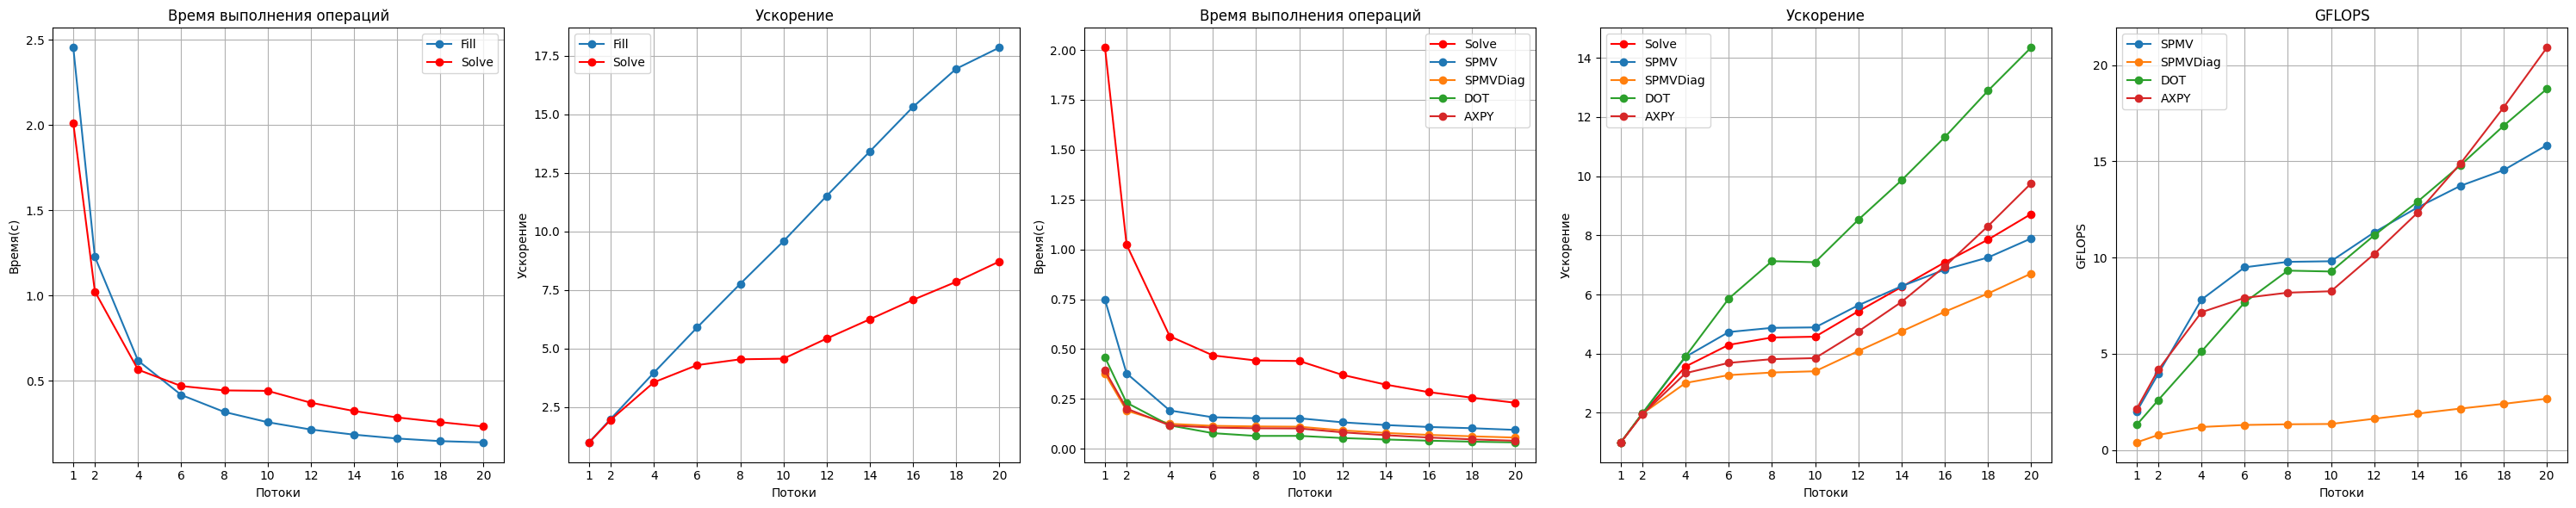

spmv: 15.846018951838667
spmv_diag: 2.670645334738686
dot: 18.772527032438926
axpy: 20.917115928134766


In [7]:
# Время выполнения операций
generation_time = np.array([
    0.231967,
    0.16626,
    0.133059,
    0.124071,
    0.121127,
    0.119937,
    0.11818,
    0.116391,
    0.1152,
    0.114645,
    0.114304
])
fill_time = np.array([
    2.45521,
    1.22674,
    0.617401,
    0.41597,
    0.316093,
    0.256148,
    0.213183,
    0.183001,
    0.160297,
    0.144898,
    0.13755
])

solve_times = np.array([
    2.01204,
    1.02342,
    0.564277,
    0.468207,
    0.44263,
    0.440061,
    0.370447,
    0.321784,
    0.284027,
    0.256235,
    0.230767
])


# Время выполнения отдельных операций (пример)
spmv_times = np.array([
    0.747088,
    0.378248,
    0.191857,
    0.157919,
    0.153352,
    0.152867,
    0.132594,
    0.119011,
    0.109217,
    0.103075,
    0.094661
])

spmv_diag_times = np.array([
    0.376647,
    0.191113,
    0.125143,
    0.115042,
    0.112029,
    0.110644,
    0.0921617,
    0.0792644,
    0.0695528,
    0.0624607,
    0.0561662
])

dot_times = np.array([
    0.458506,
    0.230932,
    0.117217,
    0.0782096,
    0.0643393,
    0.0646591,
    0.0537771,
    0.0465093,
    0.040524,
    0.0355891,
    0.0319616
])

axpy_times = np.array([
    0.391689,
    0.201355,
    0.117242,
    0.106218,
    0.102699,
    0.101777,
    0.0824489,
    0.0681512,
    0.0563955,
    0.0471484,
    0.0401585
])

# =========================
# Параметры операций
# =========================
iterations_done = 15
spmv_count = 100000000
spmv_diag_count = 10000000
dot_count = 20000000
axpy_count = 20000000

dot_count *= 2
axpy_count *= 3

# =========================
# Считаем GFLOPS для каждой операции
# =========================
spmv_gflops = (spmv_count * iterations_done) / spmv_times / 1e9
spmv_diag_gflops = (spmv_diag_count * iterations_done) / spmv_diag_times / 1e9
dot_gflops  = (dot_count  * iterations_done) / dot_times  / 1e9
axpy_gflops = (axpy_count * (iterations_done-1)) / axpy_times / 1e9

# =========================
# Считаем ускорение
# =========================
speedup_generation = generation_time[0] / generation_time
speedup_fill = fill_time[0] / fill_time
speedup_solve = solve_times[0] / solve_times
speedup_spmv  = spmv_times[0] / spmv_times
speedup_spmv_diag = spmv_diag_times[0] / spmv_diag_times
speedup_dot   = dot_times[0]  / dot_times
speedup_axpy  = axpy_times[0] / axpy_times

# =========================
# Строим графики
# =========================
plt.figure(figsize=(36, 6))

# 1️⃣ Время выполнения основных операций
plt.subplot(1, 6, 1)
plt.plot(threads, fill_time, marker='o', linestyle='-', label='Fill')
plt.plot(threads, solve_times, marker='o', linestyle='-', color='red', label='Solve')
plt.title("Время выполнения операций")
plt.xlabel("Потоки")
plt.ylabel("Время(с)")
plt.xticks(threads)
plt.legend()
plt.grid(True)

# 2️⃣ Ускорение основных операций
plt.subplot(1, 6, 2)
plt.plot(threads, speedup_fill,  marker='o', linestyle='-', label='Fill')
plt.plot(threads, speedup_solve,   marker='o', linestyle='-', color='red', label='Solve')
plt.title("Ускорение")
plt.xlabel("Потоки")
plt.ylabel("Ускорение")
plt.xticks(threads)
plt.legend()
plt.grid(True)

# 1️⃣ Время выполнения
plt.subplot(1, 6, 3)
plt.plot(threads, solve_times, marker='o', linestyle='-', color='red', label='Solve')
plt.plot(threads, spmv_times, marker='o', linestyle='-', label='SPMV')
plt.plot(threads, spmv_diag_times, marker='o', linestyle='-', label='SPMVDiag')
plt.plot(threads, dot_times, marker='o', linestyle='-', label='DOT')
plt.plot(threads, axpy_times, marker='o', linestyle='-', label='AXPY')
plt.title("Время выполнения операций")
plt.xlabel("Потоки")
plt.ylabel("Время(с)")
plt.xticks(threads)
plt.legend()
plt.grid(True)

# 2️⃣ Ускорение
plt.subplot(1, 6, 4)
plt.plot(threads, speedup_solve, marker='o', linestyle='-', color='red', label='Solve')
plt.plot(threads, speedup_spmv,  marker='o', linestyle='-', label='SPMV')
plt.plot(threads, speedup_spmv_diag, marker='o', linestyle='-', label='SPMVDiag')
plt.plot(threads, speedup_dot,   marker='o', linestyle='-', label='DOT')
plt.plot(threads, speedup_axpy,  marker='o', linestyle='-', label='AXPY')
plt.title("Ускорение")
plt.xlabel("Потоки")
plt.ylabel("Ускорение")
plt.xticks(threads)
plt.legend()
plt.grid(True)

# 3️⃣ GFLOPS
plt.subplot(1, 6, 5)
plt.plot(threads, spmv_gflops, marker='o', linestyle='-', label='SPMV')
plt.plot(threads, spmv_diag_gflops, marker='o', linestyle='-', label='SPMVDiag')
plt.plot(threads, dot_gflops, marker='o', linestyle='-', label='DOT')
plt.plot(threads, axpy_gflops, marker='o', linestyle='-', label='AXPY')
plt.title("GFLOPS")
plt.xlabel("Потоки")
plt.ylabel("GFLOPS")
plt.xticks(threads)
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

print("spmv: " + str(spmv_gflops[10]))
print("spmv_diag: " + str(spmv_diag_gflops[10]))
print("dot: " + str(dot_gflops[10]))
print("axpy: " + str(axpy_gflops[10]))
